# MONAI 4-Class Model Test


In [1]:
import copy
import json
import math
import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from monai.networks.nets import DenseNet121, EfficientNetBN, SEResNet50
from monai.transforms import Compose, RandAdjustContrast, RandAffine, RandFlip, RandGaussianNoise, RandRotate90, Resize, ScaleIntensity, ToTensor

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
IMG_SIZE = 512
NUM_EPOCHS = 12
BATCH_SIZE = 8
NUM_WORKERS = min(8, os.cpu_count() or 1)
PATIENCE = 4

DATA_ROOT = '/mounts/mecd-ap-g5/data/MIQR-CC-Dataset'
MODELS_DIR = '/mounts/mecd-ap-g5/models/model_test'
RESULTS_DIR = '/mounts/mecd-ap-g5/results/model_test'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
print('Device:', DEVICE)
print('MONAI model test outputs:', RESULTS_DIR)

Device: cuda
MONAI model test outputs: /mounts/mecd-ap-g5/results/model_test


Label                final_label  
Benign Stricture     Stricture         63
Biliary Leaks        Biliary Leaks    151
Lithiasis            Lithiasis        726
Malignant Stricture  Stricture        329
Normal               Normal           299
Name: count, dtype: int64

/tmp/ipykernel_66684/52169942.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=kept, x='final_label', order=FINAL_CLASSES, ax=ax, palette='Set2')


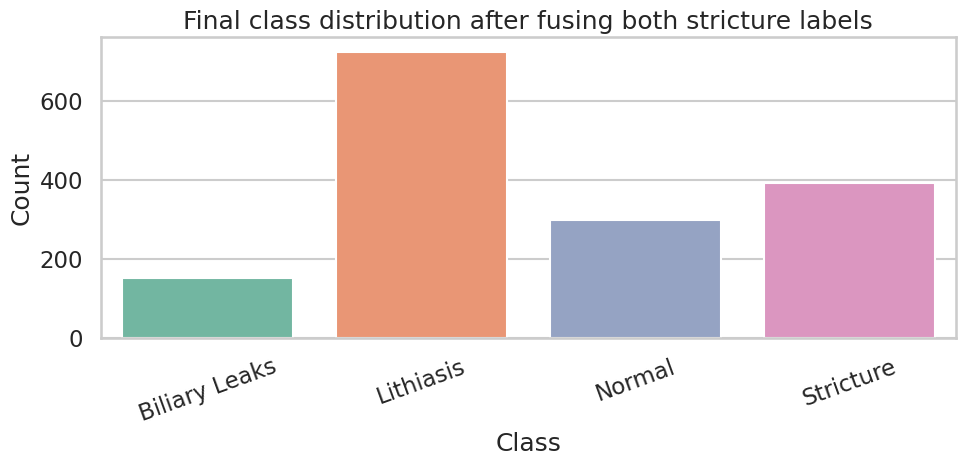

Total kept images: 1568
Final classes: ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']
Class to index: {'Biliary Leaks': 0, 'Lithiasis': 1, 'Normal': 2, 'Stricture': 3}


In [2]:
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']
FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}

metadata_path = os.path.join(DATA_ROOT, 'metadata.csv')
assert os.path.exists(metadata_path), f'Metadata not found: {metadata_path}'

meta = pd.read_csv(metadata_path)
meta.columns = [col.strip() for col in meta.columns]

kept = meta[meta['Keep'].astype(str).str.strip().str.lower().eq('keep')].copy()
kept['Label'] = kept['Label'].astype(str).str.strip()
kept = kept[~kept['Label'].str.lower().isin({'unlabelled', 'unlabeled', 'unlabbeled'})].copy()
kept['final_label'] = kept['Label'].map(FUSED_LABEL_MAP)
kept = kept[kept['final_label'].isin(FINAL_CLASSES)].copy()
kept['image_path'] = kept['processed_image_path'].apply(lambda p: os.path.join(DATA_ROOT, p))
kept = kept[kept['image_path'].apply(os.path.exists)].copy()

label_to_idx = {label: idx for idx, label in enumerate(FINAL_CLASSES)}
kept['label_idx'] = kept['final_label'].map(label_to_idx).astype(int)

display(kept[['Label', 'final_label']].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=kept, x='final_label', order=FINAL_CLASSES, ax=ax, palette='Set2')
ax.set_title('Final class distribution after fusing both stricture labels')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('Total kept images:', len(kept))
print('Final classes:', FINAL_CLASSES)
print('Class to index:', label_to_idx)

In [3]:
patient_summary = kept.groupby('patient_id').agg(
    patient_label=('final_label', lambda values: values.mode().iloc[0])
 ).reset_index()

train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label'],
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label'],
)

train_df = kept[kept['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df = kept[kept['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df = kept[kept['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print('Split sizes:')
print('  train:', len(train_df))
print('  val  :', len(val_df))
print('  test :', len(test_df))

class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = np.array(Image.open(row['image_path']).convert('RGB'))
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label_idx'])
        return image, label

def apply_clahe_rgb(image: np.ndarray, clip_limit: float = 2.0, tile_grid_size: tuple[int, int] = (8, 8)) -> np.ndarray:
    rgb = np.asarray(image).astype(np.uint8)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)
    enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

def to_channel_first(image: np.ndarray) -> np.ndarray:
    return np.moveaxis(np.asarray(image), -1, 0).copy()

resize_512 = Resize((IMG_SIZE, IMG_SIZE))
to_float = ScaleIntensity()

def build_transform(train: bool = False):
    ops = [
        lambda image: apply_clahe_rgb(image, clip_limit=2.0, tile_grid_size=(8, 8)),
        to_channel_first,
        resize_512,
        to_float,
    ]
    if train:
        ops.extend([
            RandFlip(prob=0.5, spatial_axis=0),
            RandFlip(prob=0.5, spatial_axis=1),
            RandRotate90(prob=0.5, max_k=3),
            RandAffine(prob=0.20, translate_range=(24, 24), scale_range=(0.06, 0.06), padding_mode='border'),
            RandAdjustContrast(prob=0.30, gamma=(0.75, 1.25)),
            RandGaussianNoise(prob=0.15, mean=0.0, std=0.02),
        ])
    ops.append(ToTensor())
    return Compose(ops)

train_dataset = ERCPDataset(train_df, transform=build_transform(train=True))
val_dataset = ERCPDataset(val_df, transform=build_transform(train=False))
test_dataset = ERCPDataset(test_df, transform=build_transform(train=False))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')

class_counts = train_df['label_idx'].value_counts().sort_index().reindex(range(len(FINAL_CLASSES)), fill_value=0)
class_weights = torch.tensor((class_counts.sum() / class_counts).values, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print('Train class counts:')
display(class_counts)
print('Class weights:', class_weights.detach().cpu().numpy())
print('A single sample will be transformed to:', next(iter(train_loader))[0].shape)

Split sizes:
  train: 1001
  val  : 313
  test : 254
Train class counts:


label_idx
0     78
1    468
2    206
3    249
Name: count, dtype: int64

Class weights: [12.833333   2.1388888  4.8592234  4.02008  ]
A single sample will be transformed to: torch.Size([8, 3, 512, 512])


In [4]:
def safe_macro_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    try:
        return float(roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'))
    except ValueError:
        return float('nan')

def build_densenet() -> nn.Module:
    return DenseNet121(spatial_dims=2, in_channels=3, out_channels=len(FINAL_CLASSES), pretrained=False)

def build_efficientnet() -> nn.Module:
    return EfficientNetBN(
        model_name='efficientnet-b0',
        pretrained=False,
        spatial_dims=2,
        in_channels=3,
        num_classes=len(FINAL_CLASSES),
    )

def build_seresnet() -> nn.Module:
    return SEResNet50(pretrained=False, in_channels=3, num_classes=len(FINAL_CLASSES))

MODEL_BUILDERS = {
    'densenet121': build_densenet,
    'efficientnet_b0': build_efficientnet,
    'seresnet50': build_seresnet,
}

def evaluate_model(model: nn.Module, loader: DataLoader):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_prob = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            total_loss += loss.item() * labels.size(0)
            all_true.append(labels.detach().cpu().numpy())
            all_prob.append(probs.detach().cpu().numpy())
    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    y_pred = y_prob.argmax(axis=1)
    avg_loss = total_loss / max(len(loader.dataset), 1)
    avg_acc = float((y_pred == y_true).mean())
    avg_auc = safe_macro_auc(y_true, y_prob)
    return y_true, y_pred, y_prob, avg_loss, avg_acc, avg_auc

def train_one_model(model_name: str, model_builder):
    model = model_builder().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
    checkpoint_path = os.path.join(MODELS_DIR, f'{model_name}_fused_stricture_4class.pt')
    best_state = copy.deepcopy(model.state_dict())
    best_val_auc = -math.inf
    best_epoch = -1
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        pbar = tqdm(
            train_loader,
            desc=f'Epoch {epoch}/{NUM_EPOCHS}',
            leave=False,
            dynamic_ncols=True,
            unit='batch',
        )
        for images, labels in pbar:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * labels.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            running_total += labels.size(0)

            pbar.set_postfix(
                loss=f'{running_loss / max(running_total, 1):.4f}',
                acc=f'{running_correct / max(running_total, 1):.4f}',
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

        train_loss = running_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)
        _, _, _, val_loss, val_acc, val_auc = evaluate_model(model, val_loader)
        scheduler.step(val_auc if not np.isnan(val_auc) else val_acc)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_auc': val_auc,
            'lr': optimizer.param_groups[0]['lr'],
        })

        print(
            f"{model_name} | epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f}"
        )

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, f'{model_name}_history.csv'), index=False)
    with open(os.path.join(RESULTS_DIR, f'{model_name}_history.json'), 'w') as f:
        json.dump(history, f, indent=2)

    return model, history_df, checkpoint_path, best_epoch, best_val_auc

print('Backbones ready:', ', '.join(MODEL_BUILDERS.keys()))

Backbones ready: densenet121, efficientnet_b0, seresnet50


In [ ]:
model_results = {}

for model_name, builder in MODEL_BUILDERS.items():
    print(f'\n=== Training {model_name} ===')
    model, history_df, checkpoint_path, best_epoch, best_val_auc = train_one_model(model_name, builder)
    test_true, test_pred, test_prob, test_loss, test_acc, test_auc = evaluate_model(model, test_loader)

    report_dict = classification_report(
        test_true,
        test_pred,
        labels=list(range(len(FINAL_CLASSES))),
        target_names=FINAL_CLASSES,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_csv = os.path.join(RESULTS_DIR, f'{model_name}_classification_report.csv')
    report_json = os.path.join(RESULTS_DIR, f'{model_name}_classification_report.json')
    report_df.to_csv(report_csv)
    with open(report_json, 'w') as f:
        json.dump(report_dict, f, indent=2)

    cm = confusion_matrix(test_true, test_pred, labels=list(range(len(FINAL_CLASSES))))
    cm_df = pd.DataFrame(cm, index=FINAL_CLASSES, columns=FINAL_CLASSES)
    cm_csv = os.path.join(RESULTS_DIR, f'{model_name}_confusion_matrix.csv')
    cm_df.to_csv(cm_csv)

    pred_df = pd.DataFrame({
        'y_true': test_true,
        'y_pred': test_pred,
        **{f'prob_{label}': test_prob[:, idx] for idx, label in enumerate(FINAL_CLASSES)},
    })
    pred_df.to_csv(os.path.join(RESULTS_DIR, f'{model_name}_predictions.csv'), index=False)

    model_results[model_name] = {
        'model': model,
        'history': history_df,
        'checkpoint_path': checkpoint_path,
        'best_epoch': best_epoch,
        'best_val_auc': best_val_auc,
        'test_true': test_true,
        'test_pred': test_pred,
        'test_prob': test_prob,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'test_report': report_dict,
        'test_cm': cm,
    }

    print(f"Saved checkpoint: {checkpoint_path}")
    print(f"Test accuracy: {test_acc:.4f} | Test macro AUC: {test_auc:.4f}")
    print(f"Test macro F1: {report_dict['macro avg']['f1-score']:.4f}")

results_df = pd.DataFrame([
    {
        'model': model_name,
        'best_epoch': info['best_epoch'],
        'best_val_auc': info['best_val_auc'],
        'test_loss': info['test_loss'],
        'test_acc': info['test_acc'],
        'test_auc': info['test_auc'],
        'test_macro_f1': info['test_report']['macro avg']['f1-score'],
        'test_weighted_f1': info['test_report']['weighted avg']['f1-score'],
    }
    for model_name, info in model_results.items()
]).sort_values('test_auc', ascending=False).reset_index(drop=True)

summary_csv = os.path.join(RESULTS_DIR, 'model_test_summary.csv')
results_df.to_csv(summary_csv, index=False)
display(results_df)
print('Saved summary:', summary_csv)


=== Training densenet121 ===


Epoch 1/12:   0%|          | 0/126 [00:00<?, ?batch/s]

densenet121 | epoch 01/12 | train_loss=1.4194 train_acc=0.3357 | val_loss=1.4382 val_acc=0.3163 val_auc=nan


Epoch 2/12:   0%|          | 0/126 [00:00<?, ?batch/s]

densenet121 | epoch 02/12 | train_loss=1.4043 train_acc=0.3177 | val_loss=1.3713 val_acc=0.3227 val_auc=0.5522


...

Epoch 8/12:   0%|          | 0/126 [00:00<?, ?batch/s]

densenet121 | epoch 08/12 | train_loss=1.3427 train_acc=0.4176 | val_loss=1.4996 val_acc=0.2652 val_auc=0.4055


Epoch 9/12:   0%|          | 0/126 [00:00<?, ?batch/s]

densenet121 | epoch 09/12 | train_loss=1.3140 train_acc=0.4376 | val_loss=1.4444 val_acc=0.2268 val_auc=nan


Epoch 10/12:   0%|          | 0/126 [00:00<?, ?batch/s]

In [ ]:
best_model_name = results_df.iloc[0]['model']
best_info = model_results[best_model_name]

fig, axes = plt.subplots(len(model_results), 2, figsize=(16, 5 * len(model_results)))
if len(model_results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (model_name, info) in enumerate(model_results.items()):
    hist = info['history']
    axes[row_idx, 0].plot(hist['epoch'], hist['train_loss'], label='train loss', linewidth=2)
    axes[row_idx, 0].plot(hist['epoch'], hist['val_loss'], label='val loss', linewidth=2)
    axes[row_idx, 0].set_title(f'{model_name} loss')
    axes[row_idx, 0].set_xlabel('Epoch')
    axes[row_idx, 0].set_ylabel('Loss')
    axes[row_idx, 0].legend()
    axes[row_idx, 0].grid(True, alpha=0.3)

    axes[row_idx, 1].plot(hist['epoch'], hist['val_auc'], label='val macro AUC', linewidth=2, color='darkgreen')
    axes[row_idx, 1].set_title(f'{model_name} validation AUC')
    axes[row_idx, 1].set_xlabel('Epoch')
    axes[row_idx, 1].set_ylabel('AUC')
    axes[row_idx, 1].set_ylim(0.0, 1.05)
    axes[row_idx, 1].legend()
    axes[row_idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results_df[['model', 'test_acc', 'test_auc']].melt(id_vars='model', var_name='metric', value_name='value')
sns.barplot(data=plot_df, x='model', y='value', hue='metric', ax=ax, palette='Set2')
ax.set_title('Test accuracy and macro AUC by model')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test_metric_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

y_true = best_info['test_true']
y_prob = best_info['test_prob']
y_pred = best_info['test_pred']
y_true_bin = label_binarize(y_true, classes=list(range(len(FINAL_CLASSES))))

fig, ax = plt.subplots(figsize=(8, 7))
for class_idx, class_name in enumerate(FINAL_CLASSES):
    if len(np.unique(y_true_bin[:, class_idx])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], y_prob[:, class_idx])
    class_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={class_auc:.3f})')

micro_fpr, micro_tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
micro_auc = auc(micro_fpr, micro_tpr)
ax.plot(micro_fpr, micro_tpr, color='black', linestyle='--', linewidth=2, label=f'micro-average (AUC={micro_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle=':')
ax.set_title(f'ROC curves for {best_model_name}')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{best_model_name}_roc_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

cm = best_info['test_cm']
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=FINAL_CLASSES, yticklabels=FINAL_CLASSES, ax=ax)
ax.set_title(f'Confusion matrix for {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{best_model_name}_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

best_report_df = pd.DataFrame(best_info['test_report']).transpose()
display(best_report_df)
best_report_df.to_csv(os.path.join(RESULTS_DIR, f'{best_model_name}_classification_report_table.csv'))

print('Best model:', best_model_name)
print('Summary file:', summary_csv)
print('All outputs saved under:', RESULTS_DIR)

In [ ]:
def get_best_model_for_inference():
    if 'best_info' in globals() and isinstance(best_info.get('model'), nn.Module):
        model = best_info['model']
        model = model.to(DEVICE)
        model.eval()
        return model
    checkpoint_name = f'{best_model_name}_fused_stricture_4class.pt'
    checkpoint_path = os.path.join(MODELS_DIR, checkpoint_name)
    model = MODEL_BUILDERS[best_model_name]().to(DEVICE)
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model

inference_model = get_best_model_for_inference()

inference_pool = kept[kept['image_type'].astype(str).str.upper().isin(['S', 'V'])].copy()
inference_rows = []

for image_type in ['S', 'V']:
    type_subset = inference_pool[inference_pool['image_type'].astype(str).str.upper().eq(image_type)]
    for class_name in FINAL_CLASSES:
        class_subset = type_subset[type_subset['final_label'].eq(class_name)]
        if len(class_subset) == 0:
            print(f'No sample available for {image_type} / {class_name}')
            continue
        chosen = class_subset.sample(1, random_state=SEED).iloc[0]
        inference_rows.append(chosen)

inference_df = pd.DataFrame(inference_rows).reset_index(drop=True)
display(inference_df[['image_type', 'Label', 'final_label', 'image_path']])

def predict_row(model: nn.Module, row: pd.Series):
    image = Image.open(row['image_path']).convert('RGB')
    processed = build_transform(train=False)(np.array(image))
    batch = processed.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            logits = model(batch)
            prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred_idx = int(prob.argmax())
    return image, prob, pred_idx

inference_results = []
fig, axes = plt.subplots(len(inference_df), 2, figsize=(14, 4 * max(len(inference_df), 1)))
if len(inference_df) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(inference_df.iterrows()):
    image, prob, pred_idx = predict_row(inference_model, row)
    inference_results.append({
        'image_type': row['image_type'],
        'true_label': row['final_label'],
        'pred_label': FINAL_CLASSES[pred_idx],
        'is_correct': FINAL_CLASSES[pred_idx] == row['final_label'],
        **{f'prob_{label}': float(prob[idx]) for idx, label in enumerate(FINAL_CLASSES)},
    })

    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f"{row['image_type']} | True: {row['final_label']} | Pred: {FINAL_CLASSES[pred_idx]}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].bar(FINAL_CLASSES, prob, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
    axes[row_idx, 1].set_ylim(0, 1.0)
    axes[row_idx, 1].set_title('Predicted probabilities')
    axes[row_idx, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{best_model_name}_inference_samples.png'), dpi=200, bbox_inches='tight')
plt.show()

inference_results_df = pd.DataFrame(inference_results)
display(inference_results_df)
print('Inference accuracy on selected S/V samples:', inference_results_df['is_correct'].mean() if len(inference_results_df) else float('nan'))

In [ ]:
def occlusion_sensitivity(model, image_tensor: torch.Tensor, target_idx: int, patch: int = 48, stride: int = 24):
    model.eval()
    with torch.no_grad():
        base_logits = model(image_tensor)
        base_prob = torch.softmax(base_logits, dim=1)[0, target_idx].item()

    _, _, height, width = image_tensor.shape
    heatmap = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)

    for top in range(0, height - patch + 1, stride):
        for left in range(0, width - patch + 1, stride):
            occluded = image_tensor.clone()
            occluded[:, :, top:top + patch, left:left + patch] = 0.0
            with torch.no_grad():
                logits = model(occluded)
                prob = torch.softmax(logits, dim=1)[0, target_idx].item()
            drop = base_prob - prob
            heatmap[top:top + patch, left:left + patch] += drop
            counts[top:top + patch, left:left + patch] += 1.0

    heatmap = heatmap / np.maximum(counts, 1.0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap

def get_target_layer(model):
    if hasattr(model, 'layer4'):
        return model.layer4[-1]
    if hasattr(model, 'features'):
        return model.features[-1]
    raise AttributeError(f'No known target layer for {type(model).__name__}')

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inputs, output):
            del module, inputs
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            del module, grad_input
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, target_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        score = logits[:, target_idx].sum()
        score.backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam

def overlay_cam(image_pil, cam, alpha: float = 0.5):
    image_np = np.array(image_pil)
    heat = (cam * 255).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (alpha * heat + (1 - alpha) * image_np).astype(np.uint8)

xai_rows = []
xai_fig, xai_axes = plt.subplots(len(inference_df), 4, figsize=(18, 4 * max(len(inference_df), 1)))
if len(inference_df) == 1:
    xai_axes = np.expand_dims(xai_axes, axis=0)

target_layer = get_target_layer(inference_model)
gradcam = GradCAM(inference_model, target_layer)

for row_idx, (_, row) in enumerate(inference_df.iterrows()):
    image = Image.open(row['image_path']).convert('RGB')
    processed = build_transform(train=False)(np.array(image))
    input_tensor = processed.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = inference_model(input_tensor)
        prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred_idx = int(prob.argmax())
    target_idx = int(row['label_idx'])

    occl = occlusion_sensitivity(inference_model, input_tensor, target_idx=target_idx, patch=64, stride=32)
    cam = gradcam(input_tensor, target_idx=target_idx)
    overlay = overlay_cam(image.resize((IMG_SIZE, IMG_SIZE)), cam, alpha=0.5)

    xai_axes[row_idx, 0].imshow(image.resize((IMG_SIZE, IMG_SIZE)))
    xai_axes[row_idx, 0].set_title(f"{row['image_type']} original\nTrue: {row['final_label']} | Pred: {FINAL_CLASSES[pred_idx]}")
    xai_axes[row_idx, 0].axis('off')

    xai_axes[row_idx, 1].imshow(image.resize((IMG_SIZE, IMG_SIZE)))
    xai_axes[row_idx, 1].imshow(occl, cmap='inferno', alpha=0.55)
    xai_axes[row_idx, 1].set_title('Occlusion sensitivity')
    xai_axes[row_idx, 1].axis('off')

    xai_axes[row_idx, 2].imshow(cam, cmap='jet')
    xai_axes[row_idx, 2].set_title('Grad-CAM heatmap')
    xai_axes[row_idx, 2].axis('off')

    xai_axes[row_idx, 3].imshow(overlay)
    xai_axes[row_idx, 3].set_title('Grad-CAM overlay')
    xai_axes[row_idx, 3].axis('off')

    xai_rows.append({
        'image_type': row['image_type'],
        'true_label': row['final_label'],
        'pred_label': FINAL_CLASSES[pred_idx],
        'true_prob': float(prob[target_idx]),
        'pred_prob': float(prob[pred_idx]),
    })

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'{best_model_name}_xai_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

xai_results_df = pd.DataFrame(xai_rows)
display(xai_results_df)
print('XAI samples covered image types:', sorted(xai_results_df['image_type'].unique().tolist()) if len(xai_results_df) else [])

In [ ]:
import glob

report_files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*_classification_report.csv')))
if not report_files:
    print('No classification report CSVs found in', RESULTS_DIR)
else:
    summary_rows = []
    # try to reuse existing results_df if available, otherwise attempt to read the saved summary
    rd = None
    if 'results_df' in globals():
        rd = results_df
    else:
        try:
            rd = pd.read_csv(os.path.join(RESULTS_DIR, 'model_test_summary.csv'))
        except Exception:
            rd = None

    for rpt in report_files:
        model_name = os.path.basename(rpt).replace('_classification_report.csv', '')
        print(f"\n--- Model: {model_name} ---")
        try:
            report_df = pd.read_csv(rpt, index_col=0)
            display(report_df)
        except Exception as e:
            print('Failed to read report:', e)
            continue

        cm_path = os.path.join(RESULTS_DIR, f'{model_name}_confusion_matrix.csv')
        if os.path.exists(cm_path):
            try:
                cm_df = pd.read_csv(cm_path, index_col=0)
                fig, ax = plt.subplots(figsize=(6, 5))
                sns.heatmap(cm_df.astype(int), annot=True, fmt='d', cmap='Blues', xticklabels=cm_df.columns, yticklabels=cm_df.index, ax=ax)
                ax.set_title(f'Confusion matrix - {model_name}')
                ax.set_xlabel('Predicted')
                ax.set_ylabel('True')
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print('Failed to plot confusion matrix:', e)
        else:
            print('No confusion matrix CSV found for', model_name)

        # extract macro F1 from the report if present
        macro_f1 = np.nan
        try:
            if 'macro avg' in report_df.index:
                macro_f1 = float(report_df.loc['macro avg', 'f1-score'])
            elif 'macro avg' in report_df.index:
                macro_f1 = float(report_df.loc['macro avg', 'f1-score'])
        except Exception:
            macro_f1 = np.nan

        test_acc = test_auc = np.nan
        if rd is not None:
            try:
                row = rd[rd['model'] == model_name]
                if not row.empty:
                    test_acc = float(row.iloc[0].get('test_acc', np.nan))
                    test_auc = float(row.iloc[0].get('test_auc', np.nan))
            except Exception:
                pass

        summary_rows.append({'model': model_name, 'test_acc': test_acc, 'test_auc': test_auc, 'macro_f1': macro_f1})

    summary_df = pd.DataFrame(summary_rows).sort_values('test_auc', ascending=False).reset_index(drop=True)
    display(summary_df)
    summary_csv = os.path.join(RESULTS_DIR, 'model_test_reports_aggregated.csv')
    summary_df.to_csv(summary_csv, index=False)
    print('Saved aggregated summary at', summary_csv)
